# Trabajo Práctico Especial

Señales y Sistemas (TB065) - Curso 1 - FIUBA - 2C2024  
Martin Klöckner - mklockner@fi.uba.ar  
Nicolás Chechko - vchechko@fi.uba.ar  
Matteo Aguilar Cafferata - meaguilar@fi.uba.ar  

## Primera Parte: Dominio de Tiempo

En esta primera parte del trabajo práctico se pide graficar dos señales de
audio en formato WAV en el dominio de tiempo; luego, para una de ellas
identificar diferentes notas musicales y calcular sus frecuencias fundamentales; finalmente,
para la señal de audio restante, identificar las diferencias entre instrumentos de
percusión e instrumentos armónicos.

Para la realización de los gráficos se utiliza el lenguaje de programación
[python](https://www.python.org) junto con las librerías
[scipy](https://docs.scipy.org/doc/scipy/index.html),
[matplotlib](https://matplotlib.org/) y
[numpy](https://numpy.org/doc/stable/index.html).

### Obtención y Muestra de Archivos

Empezamos importando las librerías mencionadas previamente en un nuevo script
de python. Además, se importa el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) del módulo [urllib.request](https://docs.python.org/3/library/urllib.request.html#module-urllib.request) para obtener localmente los archivos a analizar.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.io import wavfile
from urllib.request import urlretrieve

Para obtener los archivos a analizar, se define una variable para almacenar el nombre de los archivos y se descargan utilizando el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) proporcionando las respectivas urls y el nombre final que se desea que tengan los archivos una vez descargados.

In [2]:
file1_name = 'InASentimentalMood.wav'
file2_name = 'Zombie.wav'

urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/InASentimentalMood.wav', file1_name);
urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/Zombie.wav', file2_name);

Continuamos leyendo el contenido del primer archivo de nombre `InASentimentalMood.wav`,
para lo cual se utiliza el método [wavfile.read](https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html#read) de la librería [scipy](https://docs.scipy.org/doc/scipy/index.html).
Esta función devuelve los datos y la tasa de muestreo del archivo en formato WAV
cuyo nombre recibe como argumento.

In [3]:
file1_sample_rate, file1_data = wavfile.read(file1_name)

Para graficar los datos obtenidos resulta conveniente definir la función `graph_data`, la cual utiliza métodos del módulo [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot) de la librería [matplotlib](https://matplotlib.org/) para generar los gráficos pedidos.

In [4]:
def graph_data(x, y, title, figure_number=0, t=0, dt=0, a=0, da=0):
  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

  plt.plot(x, y, label='Señal de Audio')
  axis.set(xlabel='Tiempo [s]', ylabel='Amplitud')
  plt.grid(True)
  plt.legend()
  if t != 0:
    plt.xlim([t, t+dt])

  if a != 0:
    axis.axvspan(a, a+da, color='skyblue', alpha=0.50)

  plt.ylim([-1, 1])
  plt.show()

Para poder graficar los datos se necesita saber a qué tiempo corresponde cada valor de la
señal; para eso, se utiliza el método [arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange)
de la libreria [numpy](https://numpy.org/doc/stable/index.html). Este método
devuelve un arreglo de números equidistantes del largo que recibe como parámetro,
en este caso del largo de los datos leídos del archivo. Para convertirlo a segundos
se divide por la tasa de muestreo, la cual también se obtiene cuando se lee el archivo.

In [5]:
file1_time = np.arange(len(file1_data)) / file1_sample_rate

Para normalizar la amplitud de la señal entre -1 y 1 se divide por el valor máximo que toma el tipo de dato que almacena la señal. Para obtener este valor máximo se utiliza el método [iinfo](https://numpy.org/doc/stable/reference/generated/numpy.iinfo.html#numpy-iinfo) de la librería [numpy](https://numpy.org/doc/stable/index.html).

In [6]:
file1_data_normalized = file1_data / np.iinfo(file1_data.dtype).max

Se define una variable para almacenar el título de la figura, esto para posteriormente pasarlo como argumento a la función `graph_data`.

In [7]:
title = 'Gráfico de `' + str(file1_name) + '` en dominio de tiempo'

Con todos los datos ya procesados, se invoca la función `graph_data` definida previamente.

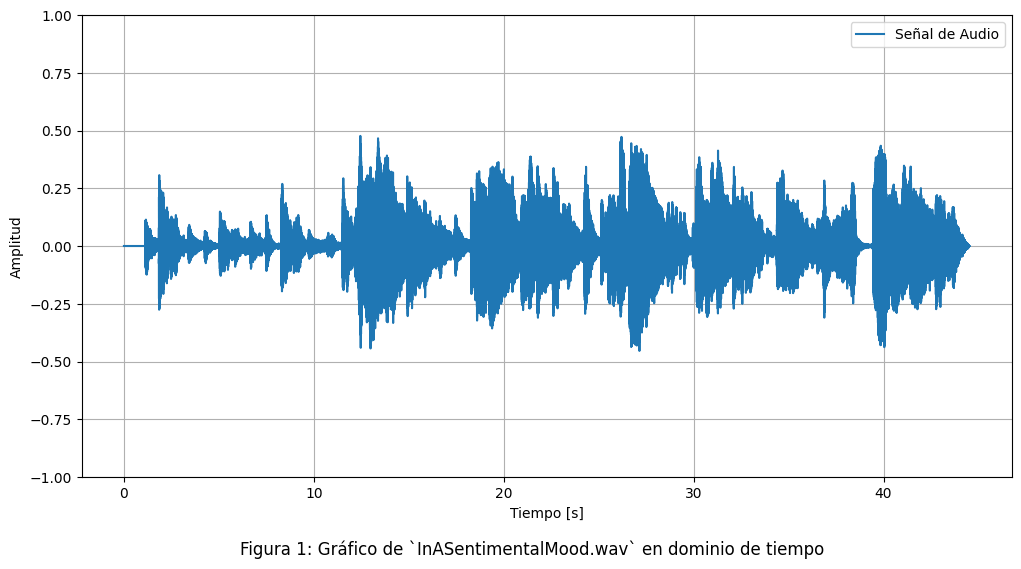

In [8]:
graph_data(file1_time, file1_data_normalized, title, 1)

Para el segundo archivo, se repite el mismo procedimiento que el realizado para el primero, solo cambia el nombre del archivo del que se obtienen los datos; en este caso siendo `Zombie.wav`.

Se obtienen los datos del archivo, se normalizan, y se construye una lista de números equidistantes que se corresponda con cada valor de la lista de datos.

In [9]:
file2_sample_rate, file2_data = wavfile.read(file2_name)
file2_time = np.arange(len(file2_data)) / file2_sample_rate
file2_data_normalized = file2_data / np.iinfo(file2_data.dtype).max

Luego de obtener y procesar los datos, se grafican utilizando la función `graph_data`:

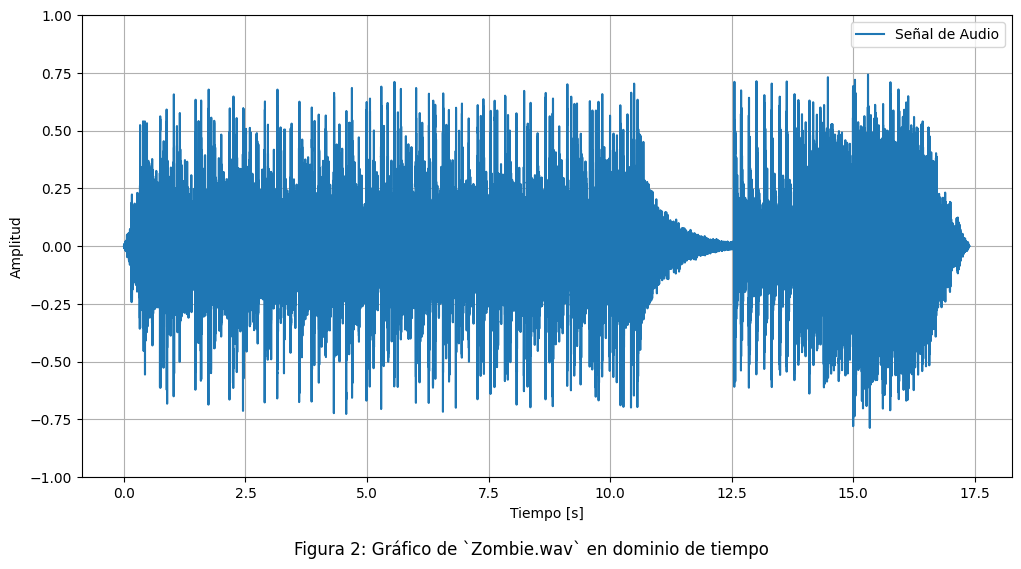

In [10]:
title = 'Gráfico de `' + str(file2_name) + '` en dominio de tiempo'
graph_data(file2_time, file2_data_normalized, title, 2)

### Identificación de Notas Musicales

Para identificar las diferentes notas musicales del primer archivo (`InASentimentalMood.wav`),
analizamos visualmente el gráfico, reduciendo la escala de tiempo a un pequeño intervalo en zonas
específicas de la figura, como se muestra en la Figura 3 a continuación, en la cual se toma
el intervalo de tiempo `[1.13, 1.30]`.

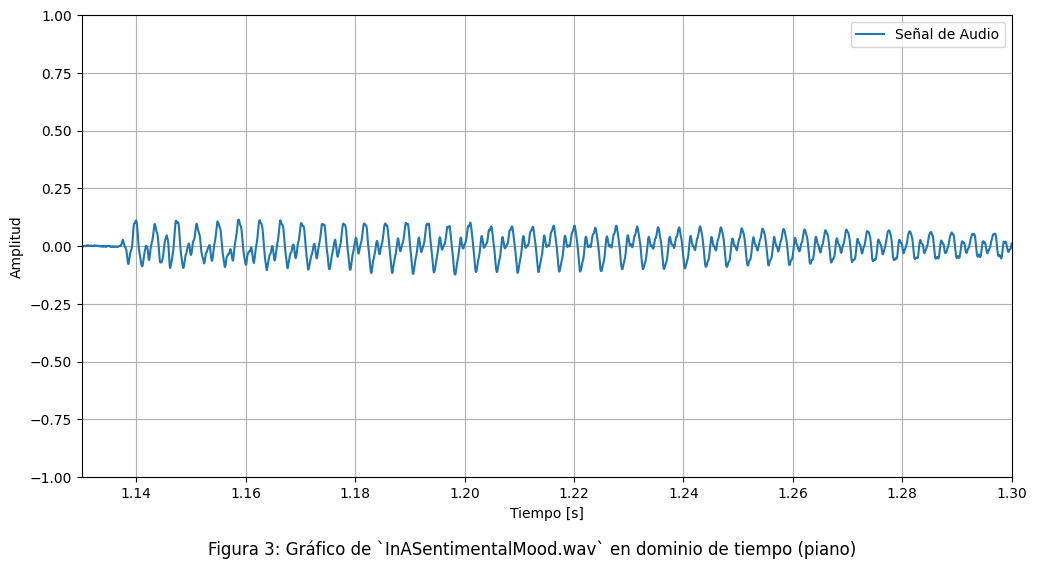

In [11]:
title = 'Gráfico de `' + str(file1_name) + '` en dominio de tiempo (piano)'
graph_data(file1_time, file1_data_normalized, title, 3, 1.13, 0.17)

Dicho intervalo de tiempo corresponde a la primera nota que puede escucharse en el archivo, producida por un piano, instrumento armónico. Si ampliamos el intervalo aún más, podremos distinguir la duración aproximada de un período (Figura 4).

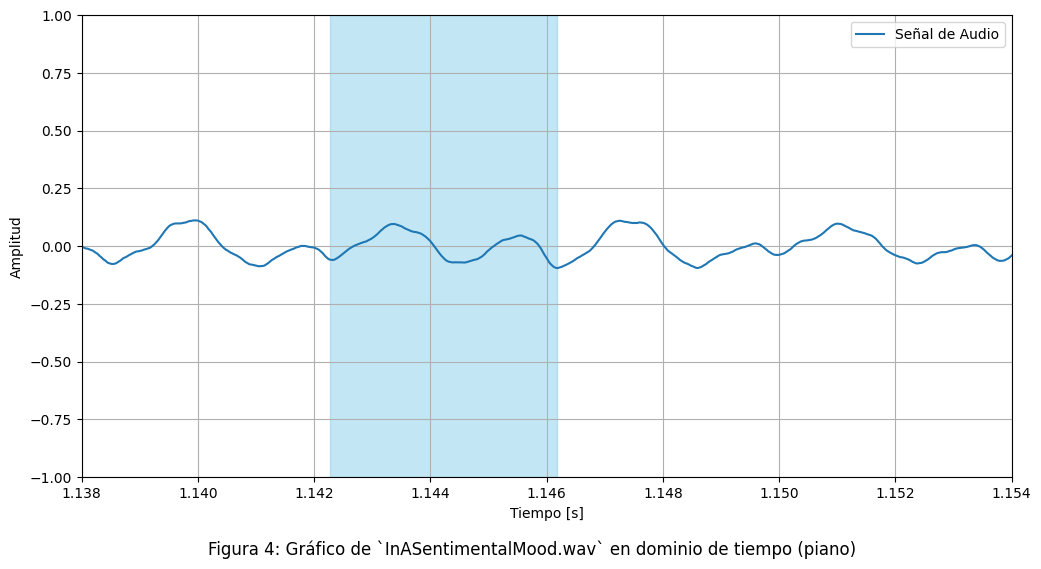

In [12]:
title = 'Gráfico de `' + str(file1_name) + '` en dominio de tiempo (piano)'
graph_data(file1_time, file1_data_normalized, title, 4, 1.138, 0.016, 1.14228, 0.0039)

Dicho periodo es de aproximadamente 3.9 milisegundos, lo cual corresponde a una frecuencia fundamental de unos 256 Hz. En música, una frecuencia de 256 Hz se acerca más a una nota `DO` de la 4° octava.

A su vez, en la Figura 5, podemos observar visualmente una nota producida por un saxofón. Como es propio de los instrumentos de viento, sus notas son más fuertes y resaltantes que las del piano, así como de mayor energía según puede evidenciarse por los picos del gráfico.

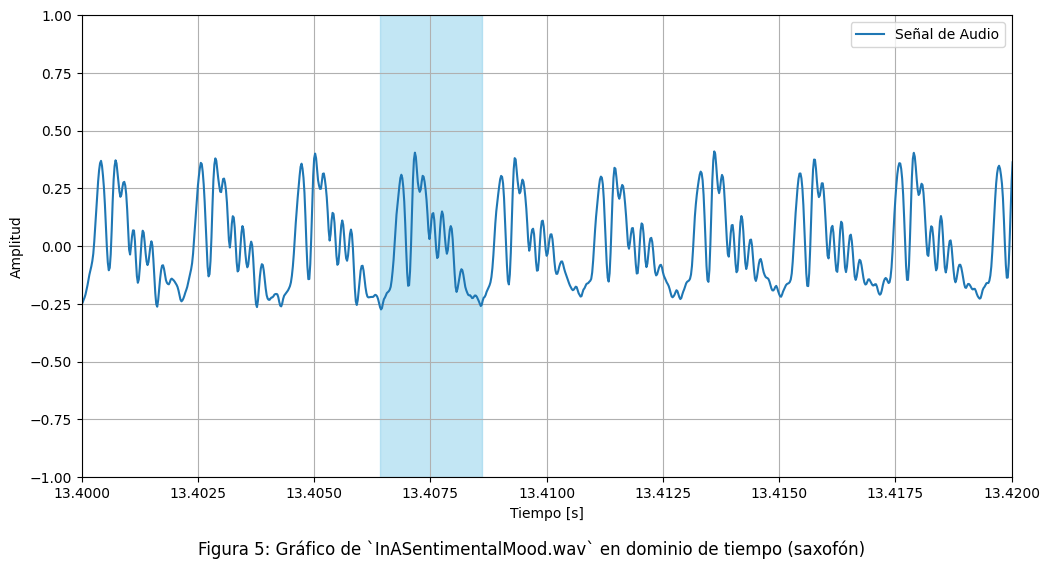

In [13]:
title = 'Gráfico de `' + str(file1_name) + '` en dominio de tiempo (saxofón)'
graph_data(file1_time, file1_data_normalized, title, 5, 13.4, 0.02, 13.40642, 0.0022)


La nota producida por este instrumento también tiene un periodo claramente distinguible, de unos 2.2 milisegundos, lo cual corresponde aproximadamente a 435 Hz y se acerca a una nota `LA` de la 4° octava (tomando como referencia el piano).

### Diferencias entre Instrumentos de Percusión y Armónicos

De manera análoga al análisis realizado para la Figura 1, se analiza la Figura 2, correspondiente
al segundo archivo, queriendo hallar diferencias notables entre los instrumentos de
percusión y los armónicos.

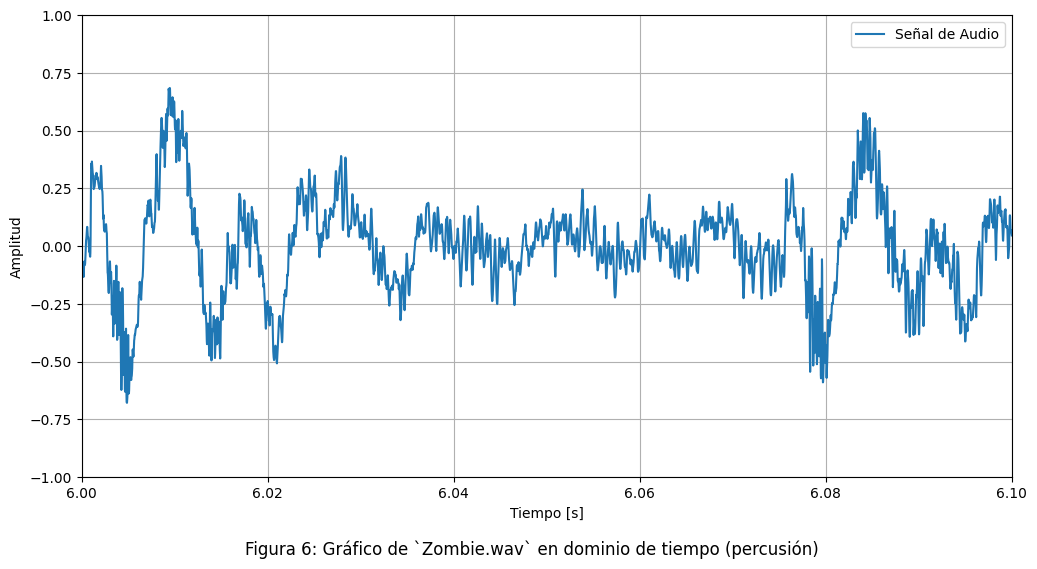

In [14]:
title = 'Gráfico de `' + str(file2_name) + '` en dominio de tiempo (percusión)'
graph_data(file2_time, file2_data_normalized, title, 6, 6.0, 0.1)

En este archivo de audio los instrumentos son enteramente de
percusión; por ello, la forma de la onda resulta más irregular y
aperiódica a la vista que las de las Figuras 4 y 5. Esto imposibilita
la distinción de una frecuencia fundamental o "notas musicales" en los
sonidos. Sin embargo, al escuchar el audio se puede notar como el rol de
estos instrumentos (batería y platillos) es el de marcar un ritmo claro
imponiendo tempos a través del contraste entre los sonidos; y por esto se
puede notar cierta repetición (a partir de cada pico por arriba de los 0.5 de amplitud) en el esquema de la onda a pesar de su
aparente falta de periodicidad.

## Segunda Parte: Dominio de Frecuencia

En esta segunda parte del trabajo práctico se pide analizar las mismas señales de audio en formato WAV que en la primer parte, pero en el dominio de la frecuencia. Para esto se utilizan las mismas herramientas: [python](https://www.python.org) junto con las librerías [scipy](https://docs.scipy.org/doc/scipy/index.html), [matplotlib](https://matplotlib.org/) y [numpy](https://numpy.org/doc/stable/index.html).

### Aplicación de la FFT

Definiendo la función `graph_fft` y tomando el intervalo de tiempo utilizado para el gráfico de la Figura 4 (correspondiente al primer archivo), el cual es `[1.138, 1.154]`, se calcula la transformada rápida de Fourier utilizando el método [fft](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fft.html#fft) de la libreria [scipy.ftt](https://docs.scipy.org/doc/scipy/tutorial/fft.html#fourier-transforms-scipy-fft), como se muestra en la Figura 7 a continuación.

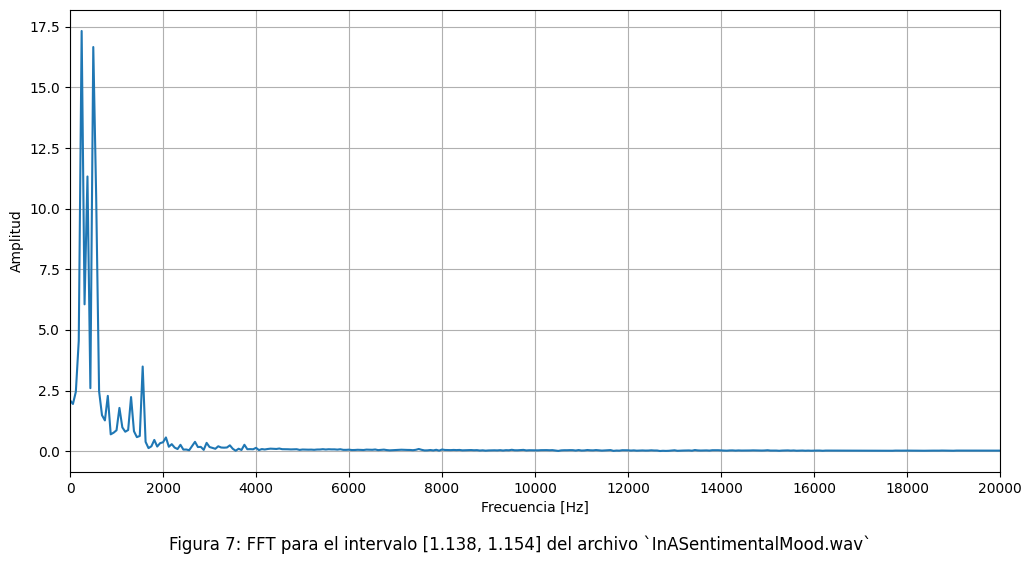

In [15]:
from scipy.fft import fft, fftfreq
from matplotlib.ticker import MultipleLocator

def graph_fft(t, dt, title, figure_number, tick, f_max):
  i = int(t*file1_sample_rate)
  di = int((t+dt)*file1_sample_rate)

  interval_data = file1_data_normalized[i:di]
  interval_fft = fft(interval_data)
  interval_freqs = fftfreq(len(interval_data), d=1/file1_sample_rate)

  # se toma la parte positiva en ambos casos (primer parte del arreglo)
  x = interval_freqs[:len(interval_data) // 2]
  y = np.abs(interval_fft[:len(interval_data) // 2])

  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)
  plt.plot(x, y)
  plt.grid()
  plt.gca().xaxis.set_major_locator(MultipleLocator(tick))
  axis.set(xlabel='Frecuencia [Hz]', ylabel='Amplitud')
  plt.xlim(0,f_max)
  plt.show()

t = 1.138
dt = 0.016
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{file1_name}`'
graph_fft(t, dt, title, 7, 2000, 20000)

Ampliando el eje de frecuencias al intervalo entre 0 Hz y 2500 Hz resulta en la Figura 8 que se muestra a continuación:

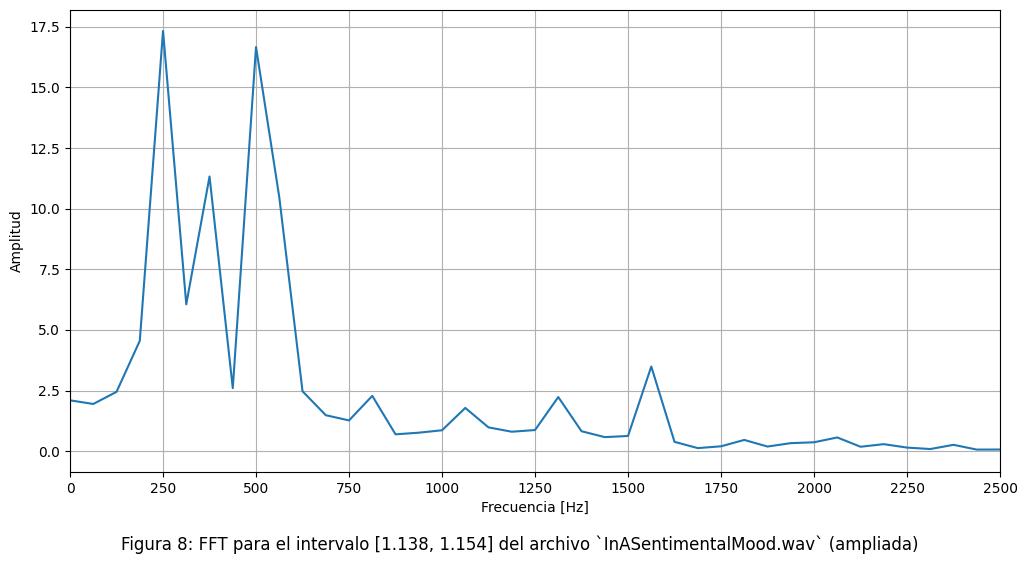

In [16]:
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{file1_name}` (ampliada)'
graph_fft(t, dt, title, 8, 250, 2500)

Como se puede ver, los dos picos más significativos del espectro obtenido por FFT se ubican en las frecuencias 256 Hz y 512 Hz, la primera de ellas correspondiendo con la frecuencia fundamental calculada anteriormente (256 Hz).

Ahora haremos lo mismo para el intervalo de tiempo utilizado en la Figura 5, el cual es `[13.400, 13.420]` y corresponde al saxofón. Presentamos directamente la FFT ampliada sobre el intervalo `[0 Hz, 2500 Hz]` en la Figura 9:

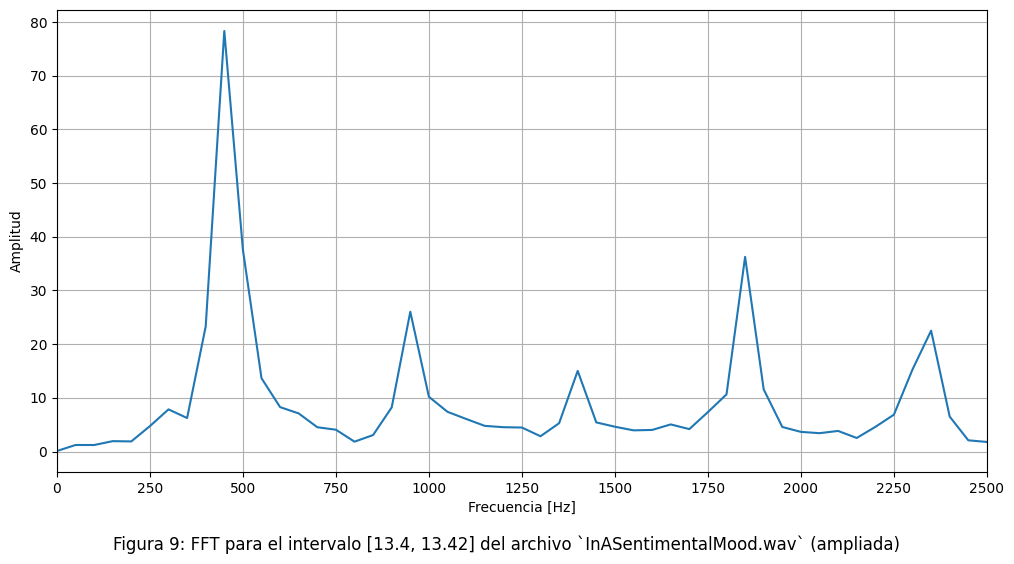

In [17]:
t = 13.400
dt = 0.020
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{file1_name}` (ampliada)'
graph_fft(t, dt, title, 9, 250, 2500)

Nuevamente podemos ver como el pico más significativo se ubica en la frecuencia que coincide con la calculada previamente, en este caso de unos 435 Hz.

###FFT con Notas Distintas

Usando la función ya definida `graph_fft` en el intervalo seleccionado `[34.4, 34.6]` podemos analizar lo que sucede cuando una región abarca dos notas musicales distintas. En la Figura 10 vemos los picos en las frecuencias 465 Hz y 935 Hz, que corresponden a las notas La y Do respectivamente.

Los demás armónicos quedan sumamente achatados en contraste con la intensidad de las frecuencias fundamentales de las dos notas.



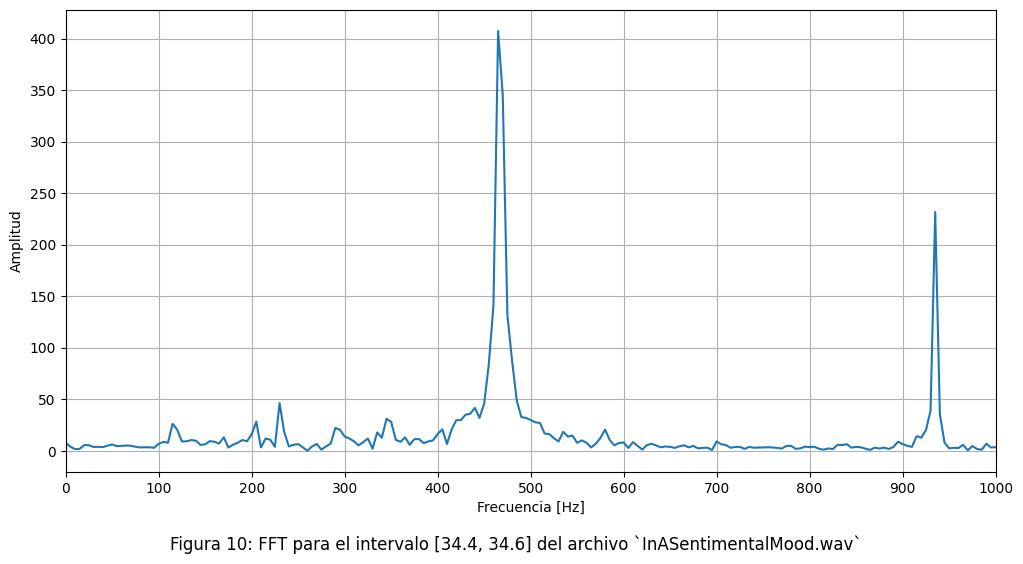

In [18]:
t = 34.4
dt = 0.2
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{file1_name}`'
graph_fft(t, dt, title, 10, 100, 1000)

### Visualización de Cambio de Notas Mediante Espectrogramas

Los espectrogramas son una forma de visualizar como varía el contenido frecuencial a lo largo del tiempo. Se realizan calculando y apilando la aplicación de la FFT a intervalos regulares. Como involucran tres variables (tiempo, frecuencia y amplitud), la amplitud o intensidad de cierta frecuencia se representa como un color, yendo desde violeta (amplitud muy baja/poco significativa) hasta naranja (amplitud significativa).

Realizaremos el espectrograma de dos intervalos donde haya cambio de notas, para poder observar este cambio en frecuencia, utilizando la función [spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html) de la librería [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html).

En la Figura 11 se puede ver el análisis para el intervalo `[2.230, 3.000]`.

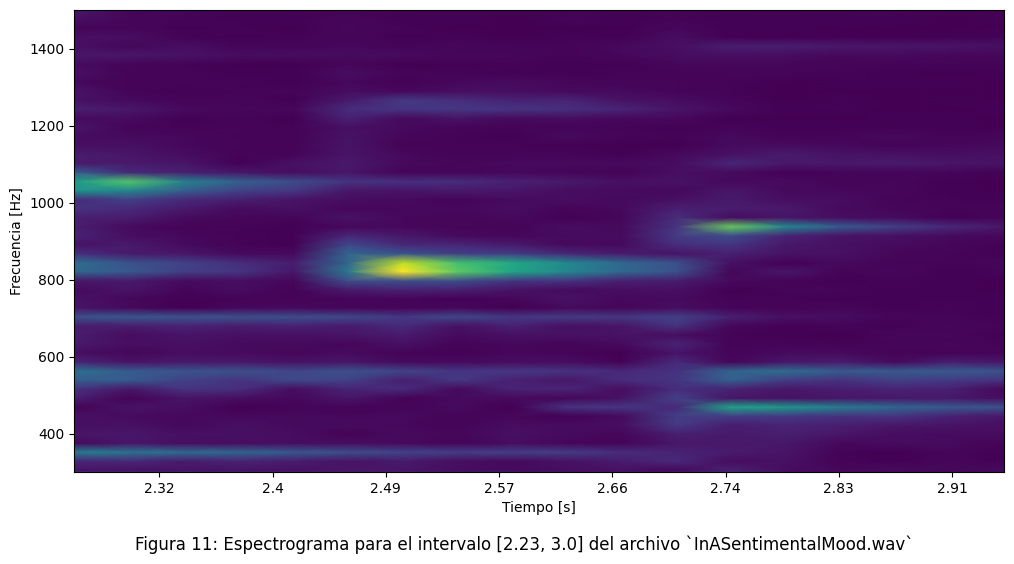

In [19]:
from scipy.signal import spectrogram

t=2.230
dt=0.770

i = int(t*file1_sample_rate)
di = int((t+dt)*file1_sample_rate)

interval_data = file1_data_normalized[i:di]

f, time, Sxx = spectrogram(interval_data, fs=file1_sample_rate, nperseg=2048, noverlap=64)

figure, axis = plt.subplots(num=title, figsize=(12, 6))
figure_caption = f'Figura 11: Espectrograma para el intervalo [{t}, {t+dt}] del archivo `{file1_name}`'
figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

# Ajuste en el eje X.
ticks = np.linspace(0, dt, 10)
tick_labels = np.linspace(t, t + dt, 10)
plt.xticks(ticks, labels=np.round(tick_labels, 2))

plt.pcolormesh(time, f, Sxx**0.5, shading='gouraud') # **0.5 (raíz cuadrada) permite una mejor visualización.
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.ylim(300, 1500)
plt.show()

En este intervalo, se tocan 3 notas distintas de piano. El cambio puede distinguirse en el espectrograma, donde se ve el paso en frecuencia de ~1050 Hz, a ~825 Hz, a ~950 Hz.

Realizamos lo mismo para el intervalo `[40.575, 41.850]`, donde se toca el saxofón.

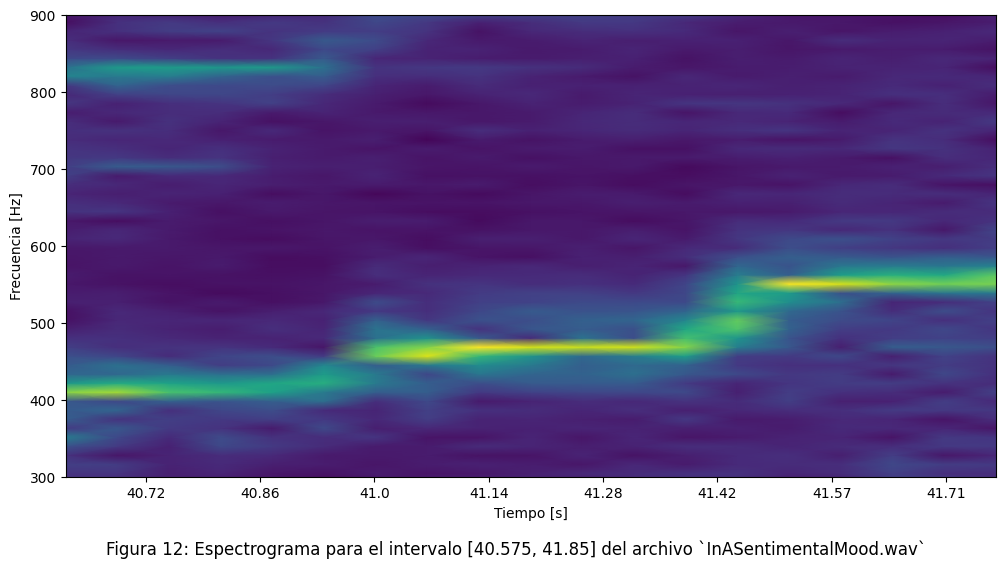

In [20]:
t=40.575
dt=1.275

i = int(t*file1_sample_rate)
di = int((t+dt)*file1_sample_rate)

interval_data = file1_data_normalized[i:di]

f, time, Sxx = spectrogram(interval_data, fs=file1_sample_rate, nperseg=4096, noverlap=1024)

figure, axis = plt.subplots(num=title, figsize=(12, 6))
figure_caption = f'Figura 12: Espectrograma para el intervalo [{t}, {t+dt}] del archivo `{file1_name}`'
figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

# Ajuste en el eje X.
ticks = np.linspace(0, dt, 10)
tick_labels = np.linspace(t, t + dt, 10)
plt.xticks(ticks, labels=np.round(tick_labels, 2))

plt.pcolormesh(time, f, Sxx**0.25, shading='gouraud') # **0.25 permite una mejor visualización.
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.ylim(300, 900)
plt.show()

En este intervalo, se distingue claramente el cambio en las notas tocadas por el saxofón, explicitadas por el paso en frecuencia de ~410 Hz, a ~460 Hz, a ~550 Hz.

### Filtro Butterworth

Ahora, analizaremos cómo afecta a la señal de audio `InASentimentalMood.wav` la aplicación de un filtro pasabajos Butterworth con distintas frecuencias de corte (500 Hz, 1000 Hz y 2000 Hz). Para ello utilizamos las funciones [butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) y [filtfilt](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html) de [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html).

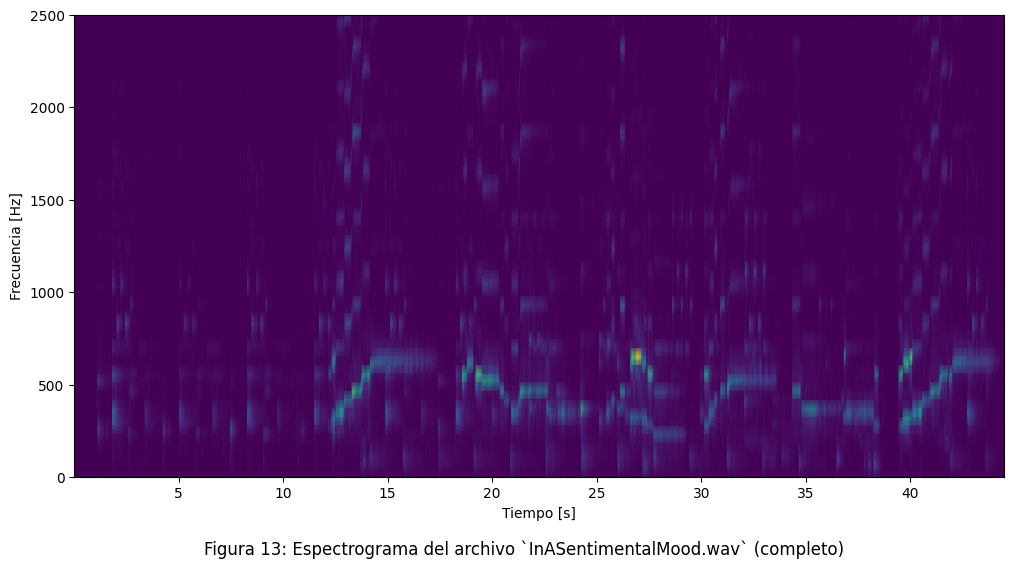

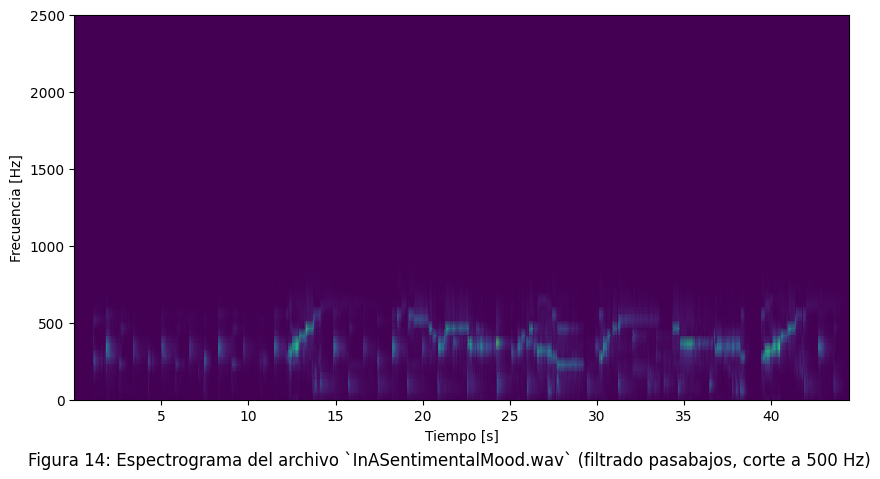

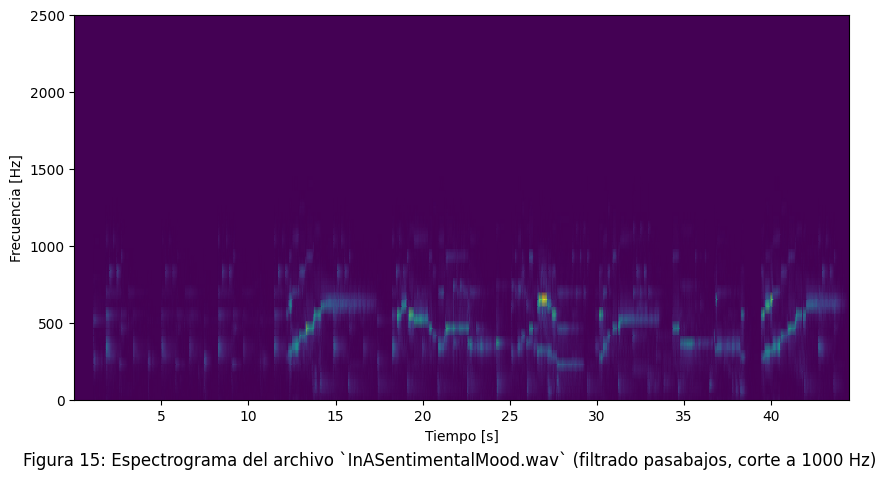

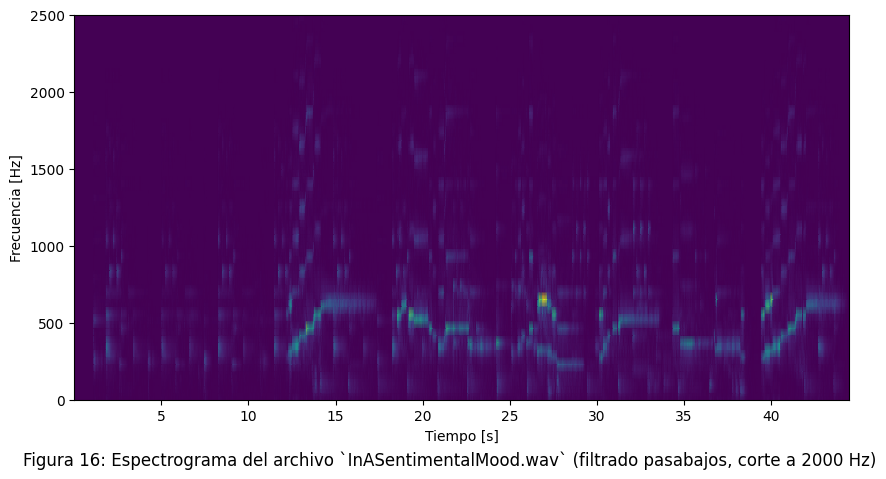

In [21]:
from scipy.signal import butter, filtfilt

def butterworth_filter(data, cutoff, fs, order=5):
  nyquist = 0.5 * fs
  normal_cutoff = cutoff / nyquist
  b, a = butter(order, normal_cutoff, btype='low', analog=False)
  filtered_data = filtfilt(b, a, data)
  return filtered_data

cutoff_frequencies = [500, 1000, 2000]  # Frecuencias de corte.
filtered_signals = [butterworth_filter(file1_data_normalized, cutoff, file1_sample_rate) for cutoff in cutoff_frequencies]

f, time, Sxx = spectrogram(file1_data_normalized, fs=file1_sample_rate, nperseg=1024, noverlap=512)

figure, axis = plt.subplots(num=title, figsize=(12, 6))
figure_caption = f'Figura 13: Espectrograma del archivo `{file1_name}` (completo)'
figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

plt.pcolormesh(time, f, Sxx**0.5, shading='gouraud', cmap='viridis') # **0.5 (raíz cuadrada) permite una mejor visualización.
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.ylim(0, 2500)
plt.show()

i = 0

for cutoff, filtered_data in zip(cutoff_frequencies, filtered_signals):
  print('\n')

  f, time, Sxx = spectrogram(filtered_data, fs=file1_sample_rate, nperseg=1024, noverlap=512)

  figure, axis = plt.subplots(num=title, figsize=(10, 5))
  figure_caption = f'Figura {i+14}: Espectrograma del archivo `{file1_name}` (filtrado pasabajos, corte a {cutoff_frequencies[i]} Hz)'
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

  plt.pcolormesh(time, f, Sxx**0.5, shading='gouraud', cmap='viridis')
  plt.ylabel('Frecuencia [Hz]')
  plt.xlabel('Tiempo [s]')
  plt.ylim(0, 2500)
  plt.show()

  i=i+1

Como puede observarse en las Figuras 14, 15 y 16; a diferencia del espectrograma de la señal original (Figura 13), se elimina cierta coloración celeste aproximadamente a partir de la frecuencia de corte del filtro aplicado. Esto es más notorio en la Figura 14, donde el color por encima de los 500 Hz es uniformemente violeta.

Entonces, la aplicación de los filtros sí produce pérdida de información, al eliminar (atenuar) las frecuencias por encima de la frecuencia de corte.

Ahora seleccionaremos una nota musical y veremos cómo cambia la forma de la señal en el dominio temporal al aplicar el filtro para cada frecuencia. Lo haremos para la nota del saxofón ya analizada previamente en las Figuras 5 y 9, correspondiente al intervalo `[13.400, 13.420]`.

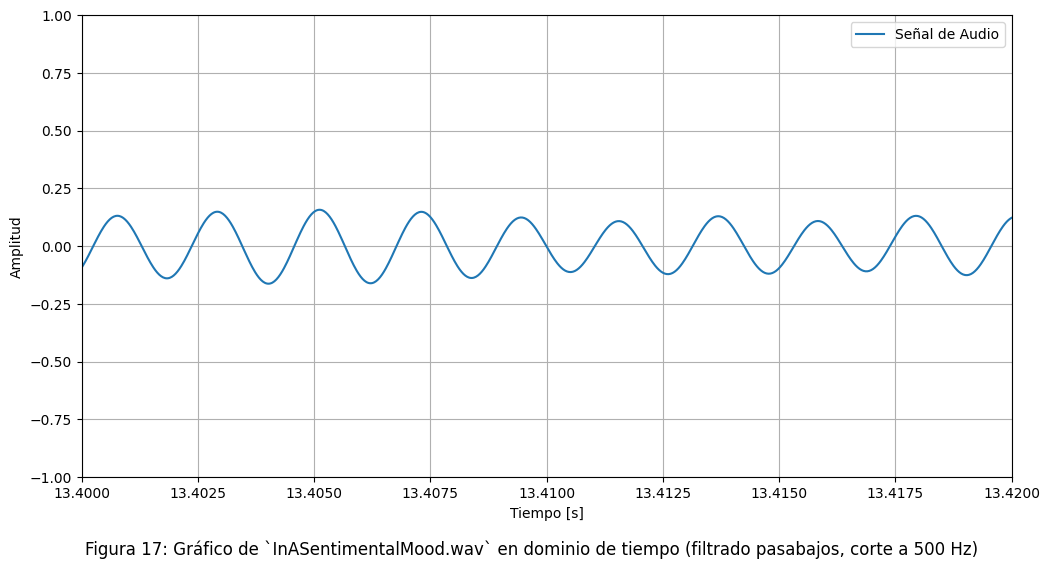

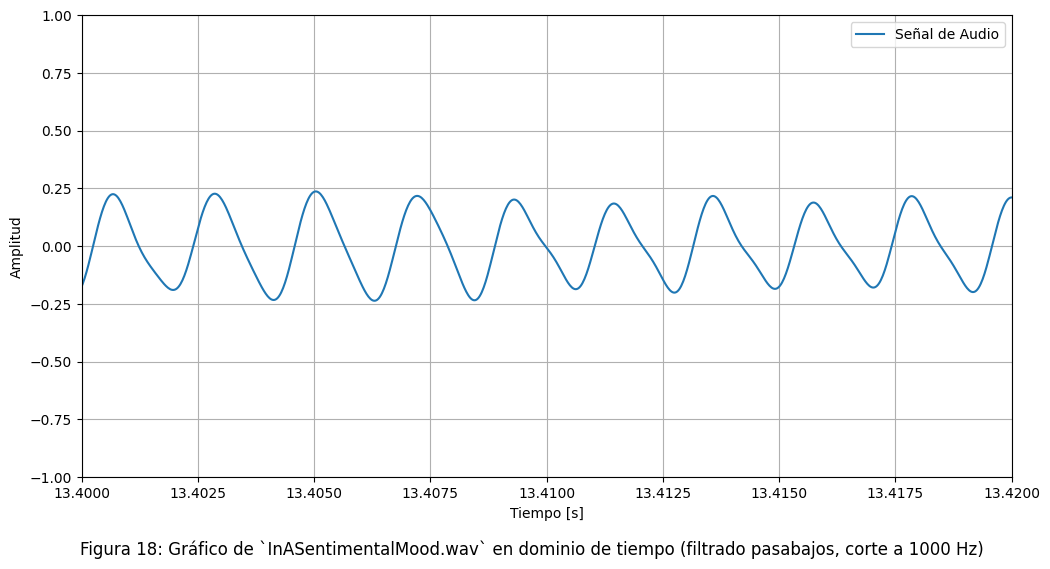

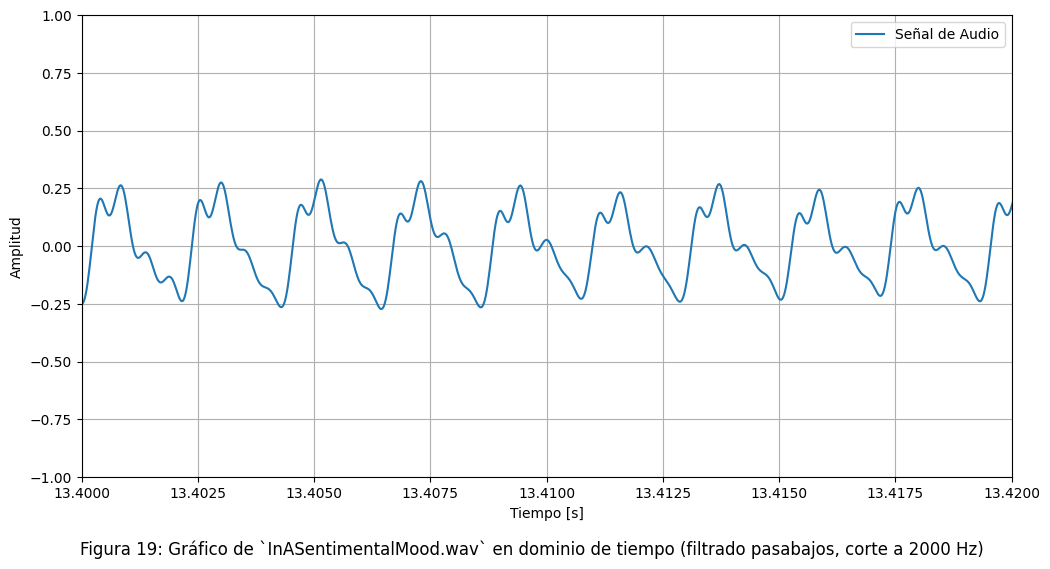

In [22]:
i = 0

for cutoff, filtered_data in zip(cutoff_frequencies, filtered_signals):
  title = 'Gráfico de `' + str(file1_name) + f'` en dominio de tiempo (filtrado pasabajos, corte a {cutoff_frequencies[i]} Hz)'
  graph_data(file1_time, filtered_data, title, 17+i, 13.4, 0.02)
  i=i+1
  print('\n')

Resulta evidente así que la forma de la señal en el dominio temporal cambia bruscamente bajo la aplicación del filtro Butterworth con distintas frecuencias de corte. La señal en la Figura 17 resulta muy simple, siendo prácticamente una senoidal de 435 Hz, mientras que en las Figuras 18 y 19 tanto el contenido frecuencial armónico como la forma en el dominio temporal se complejizan.